In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn

from conformal import get_conformal_module, get_percentile, clip_scores, calibrate_residual
from conformal_baselines import calc_baseline_mets
from data import get_dataloaders
from model import NN
from trainer import Trainer, get_optimizer, get_scheduler
from config import get_config_by_name
import utils as utils


In [2]:
config = get_config_by_name('tissuemnist')
config.conformal_module_name = 'aps'
config.num_epochs = 100
config.use_score_clipping = False 
config.plat_scaling = False

utils.seed_everything(config.seed)
# utils.create_logger(config.exp_dir, config.dump_log)

logging.info('Config:')
for k, v in config.items():
    logging.info(f'{k}: {v}')
logging.info('')

conformal_module = get_conformal_module(config.conformal_module_name)
dls, t = get_dataloaders(config, conformal_module)
train_dl = dls['train']
valid_dl = dls['valid']
test_dl = dls['test']
baseline_mets = calc_baseline_mets(train_dl, valid_dl, alpha=config.alpha, k_raps=config.k_raps)


In [3]:
model = NN(input_dim=config.input_dim,
            hidden_dim=config.hidden_dim,
            norm=config.norm,
            drop_rate=config.drop_rate,
            criteria_name=config.criteria_name)
model = model.to(config.device)
logging.info(model)

optimizer = get_optimizer(model, config)
scheduler = get_scheduler(optimizer, config)

criteria = nn.MSELoss()
trainer = Trainer(criteria=criteria,
                    metric_logger=utils.RegressionMetricLogger,
                    config=config)

trainer.fit(model=model,
            train_loader=train_dl,
            test_loader=valid_dl,
            optimizer=optimizer,
            scheduler=scheduler,
            valid_loader=valid_dl)

311it [00:01, 195.53it/s]
311it [00:01, 292.08it/s]
311it [00:01, 286.87it/s]
311it [00:01, 259.20it/s]
311it [00:01, 254.33it/s]
/home/royhirsch/miniconda3/envs/conf/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:152: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)
311it [00:01, 252.86it/s]
311it [00:01, 247.98it/s]
311it [00:01, 209.96it/s]
311it [00:01, 202.50it/s]
311it [00:01, 234.90it/s]
311it [00:01, 287.05it/s]
311it [00:01, 267.43it/s]
311it [00:01, 247.43it/s]
311it [00:01, 257.39it/s]
311it [00:01, 255.69it/s]
311it [00:01, 257.29it/s]
311it [00

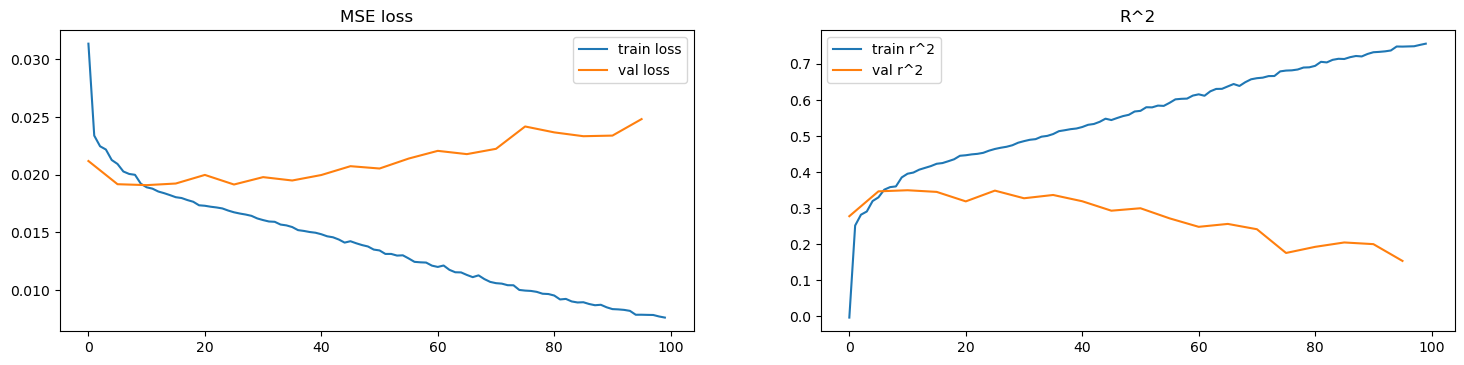

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x_val = np.arange(0, len(trainer.history['loss']), config.val_interval)

plt.figure(figsize=(18,18))
plt.subplot(4,2,1)
plt.plot(trainer.history['loss'], label='train loss')
plt.plot(x_val, trainer.history['val_loss'], label='val loss')
plt.title('MSE loss')
plt.legend()

plt.subplot(4,2,2)
plt.plot(trainer.history['r^2'], label='train r^2')
plt.plot(x_val, trainer.history['val_r^2'], label='val r^2')
plt.title('R^2')
plt.legend()

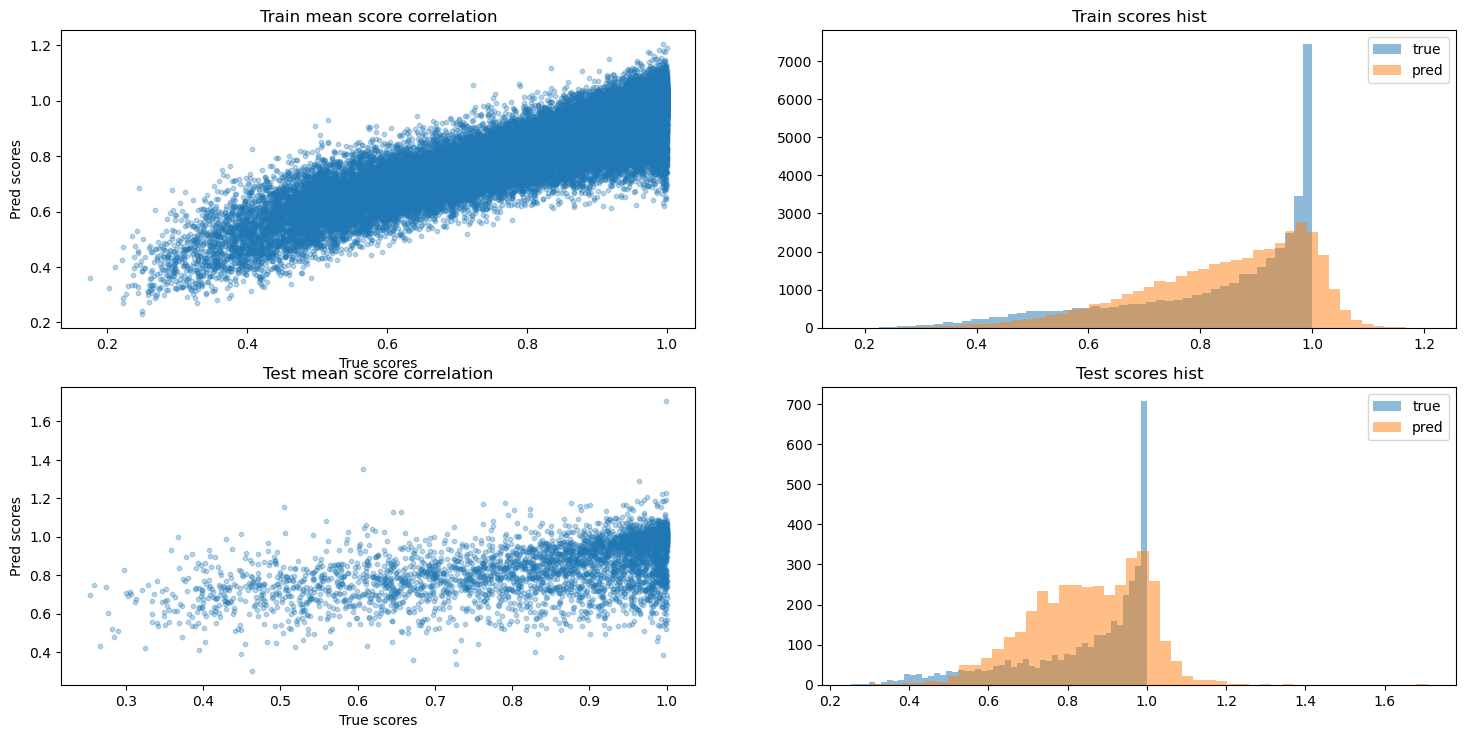

In [11]:
train_predict_out = trainer.predict(model, train_dl)
test_predict_out = trainer.predict(model, test_dl)

plt.figure(figsize=(18,8.5))

plt.subplot(2,2,1)
plt.scatter(train_predict_out['true_scores'], train_predict_out['pred_scores'], s=10, alpha=0.3)
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Train mean score correlation')


plt.subplot(2,2,2)
_ = plt.hist(train_predict_out['true_scores'], bins=50, label='true', alpha=0.5)
_ = plt.hist(train_predict_out['pred_scores'], bins=50, label='pred', alpha=0.5)
plt.legend()
plt.title('Train scores hist')

plt.subplot(2,2,3)

plt.scatter(test_predict_out['true_scores'], test_predict_out['pred_scores'], s=10, alpha=0.3)
plt.xlabel('True scores')
plt.ylabel('Pred scores')
plt.title('Test mean score correlation')

plt.subplot(2,2,4)
_ = plt.hist(test_predict_out['true_scores'], bins=50, label='true', alpha=0.5)
_ = plt.hist(test_predict_out['pred_scores'], bins=50, label='pred', alpha=0.5)
plt.legend()
plt.title('Test scores hist')

plt.show()


# Dev

In [53]:
import numpy as np
from conformal import divide, calc_correction_bias

################
# debug: 
# make the NN prediction - zeros
# enter the perfect scores as input
# look at specific examples

# train the model over 0 * true_class
# then add the random to the quantization and the label generation (same seed)

# to divide to groups by the max_prob
# to go back to the APS results and 

# to validate the results of the NN
################

alpha = 0.1
eps = 1e-7

train_predict_out = trainer.predict(model, train_dl)
test_predict_out = trainer.predict(model, test_dl)
max_value = conformal_module.get_max_value(8)

# calib_true_scores  = get_random_scores(train_predict_out['cls_probs'], train_predict_out['cls_labels'])
calib_true_scores = train_predict_out['true_scores']

calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

# valid_true_scores  = get_random_scores(test_predict_out['cls_probs'], test_predict_out['cls_labels'])
valid_true_scores = test_predict_out['true_scores']

valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_pred_scores = get_quantized_scores(calib_pred_scores, calib_probs)
valid_pred_scores = get_quantized_scores(valid_pred_scores, valid_probs)

# calib_pred_scores = np.zeros_like(calib_pred_scores)
# valid_pred_scores = np.zeros_like(valid_pred_scores)

# calib_pred_scores = calib_true_scores
# valid_pred_scores = valid_true_scores

num_scores_bigger_then_one(valid_pred_scores)

diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = calib_true_scores - calib_pred_scores

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)
print(f'qhat={qhat}')

valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# valid_pred_scores = valid_pred_scores + qhat

num_scores_bigger_then_one(valid_pred_scores)
valid_pred_scores = np.clip(valid_pred_scores, a_min=valid_probs.max(1), a_max=max_value)
num_scores_bigger_then_one(valid_pred_scores)

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(valid_pred_scores, valid_probs)
# sets = get_random_sets_v3(valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
print(calibrated_test_mets)



0.11607615018508725
qhat=0.2120898950483402
0.1885245901639344
0.1885245901639344
{'size_mean': 3.2363828662083556, 'size_std': 1.8931445332007741, 'acc': 0.9161819143310418}


In [13]:
baseline_mets['aps_randomized']

{'size_mean': 2.3365943945002643,
 'size_std': 1.2242606782474037,
 'qhat': 0.901237708019801,
 'acc': 0.9164463246959281}

## Functions

In [7]:
def get_quantized_scores_v4(pred_scores, probs):
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        sorted_p = np.sort(p)[::-1]
        cumsum = sorted_p.cumsum()
        for i in range(len(cumsum)):
            if cumsum[i] > s:
                break
        # print(i)
        if i == 0:
            quantized_scores.append(cumsum[i])
        else:
            quantized_scores.append((cumsum[i] + cumsum[i-1])/2.)
    return np.asarray(quantized_scores)

def get_quantized_scores_v3(pred_scores, probs):
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        sorted_p = np.sort(p)[::-1]
        cumsum = sorted_p.cumsum()
        for i in range(len(cumsum)):
            if cumsum[i] > s:
                break
        # print(i)
        if i == 0:
            quantized_scores.append(cumsum[i] * 0.5)
        else:
            quantized_scores.append((cumsum[i] + cumsum[i-1])/2.)
    return np.asarray(quantized_scores)

def get_quantized_scores_v2(pred_scores, probs):
    # take 0.5 into consideration
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        p = np.sort(p)[::-1]
        cumsum = []
        for i in range(len(p)):
            cumsum.append(sum(p[:i]) + 0.5 * p[i])
        cumsum = np.asarray(cumsum)
        # print(cumsum)
        ind = np.argmin(np.abs(cumsum - s))
        quantized_scores.append(cumsum[ind])
    return np.asarray(quantized_scores)

def get_random_sets_v4(valid_pred_scores, valid_probs):
    val_pi = valid_probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(valid_probs, val_pi, axis=1).cumsum(axis=1)

    n_val = val_srt.shape[0]
    cumsum_index = np.sum(val_srt <= np.expand_dims(valid_pred_scores, 1), axis=1)
    high = val_srt[np.arange(n_val), cumsum_index]
    low = np.zeros_like(high)
    low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
    prob = 0.5
    rv = np.random.binomial(1,prob,size=(n_val))
    randomized_threshold = low
    randomized_threshold[rv == 1] = high[rv == 1]
    randomized_threshold = np.maximum(randomized_threshold, val_srt[:, 0])
    prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)

    sets = []
    for p in prediction_sets:
        sets.append(tuple(np.where(p == True)[0].tolist()))
    return sets

def get_random_sets_v3(valid_pred_scores, valid_probs):
    val_pi = valid_probs.argsort(1)[:, ::-1]
    val_srt = np.take_along_axis(valid_probs, val_pi, axis=1).cumsum(axis=1)

    n_val = val_srt.shape[0]
    cumsum_index = np.sum(val_srt <= np.expand_dims(valid_pred_scores, 1), axis=1)
    high = val_srt[np.arange(n_val), cumsum_index]
    low = np.zeros_like(high)
    low[cumsum_index > 0] = val_srt[np.arange(n_val), cumsum_index-1][cumsum_index > 0]
    prob = (valid_pred_scores - low)/(high - low)
    rv = np.random.binomial(1,prob,size=(n_val))
    randomized_threshold = low
    randomized_threshold[rv == 1] = high[rv == 1]
    randomized_threshold = np.maximum(randomized_threshold, val_srt[:,0])
    prediction_sets = np.take_along_axis(val_srt <= randomized_threshold[:,None], val_pi.argsort(axis=1), axis=1)

    sets = []
    for p in prediction_sets:
        sets.append(tuple(np.where(p == True)[0].tolist()))
    return sets

def num_scores_bigger_then_one(scores):
    print(len(np.where(scores >= 0.99)[0]) / len(scores))

def get_random_sets_v2(scores, probs):
    sets = []
    for s, p, in zip(scores, probs):
        sorted_p = np.sort(p)[::-1]
        argsort_p = np.argsort(p)[::-1]
        cumsum_p = np.cumsum(sorted_p)            

        inds = np.where(cumsum_p < (s - 1e-8))[0]
        if len(inds):
            ind = inds[-1]
            prob = (cumsum_p[ind + 1] - s) / (cumsum_p[ind + 1] - cumsum_p[ind])
            if np.random.binomial(1, prob):
                ind += 1
        else:
            ind = len(p) - 1
        sets.append(tuple(argsort_p[:ind + 1]))
    return sets

def get_quantized_scores(pred_scores, probs):
    quantized_scores = []
    for s, p in zip(pred_scores, probs):
        cumsum = np.sort(p)[::-1].cumsum()
        ind = np.argmin(np.abs(cumsum - s))
        quantized_scores.append(cumsum[ind])
    return np.asarray(quantized_scores)

def get_random_scores(probs, labels):
    scores = []
    for p, l in zip(probs, labels):
            true_class_p = p[l]
            score = np.sum(p[p > true_class_p]) + 0.5 * true_class_p 
            scores.append(score)
    return np.asarray(scores)



# A try-out division to groups

In [70]:
import numpy as np
from conformal import divide, calc_correction_bias

alpha = 0.1
eps = 1e-7

train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

max_value = conformal_module.get_max_value(8)
calib_true_scores  = get_random_scores(train_predict_out['cls_probs'], train_predict_out['cls_labels'])
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores  = get_random_scores(test_predict_out['cls_probs'], test_predict_out['cls_labels'])
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_quantized_scores_reg, calib_quantized_scores_reg_ind, calib_quantized_scores_special, calib_quantized_scores_special_ind = get_quantized_scores_two_groups(calib_pred_scores, calib_probs)

valid_quantized_scores_reg, valid_quantized_scores_reg_ind, valid_quantized_scores_special, valid_quantized_scores_special_ind = get_quantized_scores_two_groups(valid_pred_scores, valid_probs)

diff_reg = (calib_true_scores[calib_quantized_scores_reg_ind] - calib_quantized_scores_reg) / (max_value - calib_probs[calib_quantized_scores_reg_ind,:].max(1) + eps)
diff_special = (calib_true_scores[calib_quantized_scores_special_ind] - calib_quantized_scores_special) / (max_value - calib_probs[calib_quantized_scores_special_ind, :].max(1) + eps)

n = len(diff_reg)
qhat_reg = np.quantile(diff_reg, np.ceil((n + 1) * (1 - alpha)) / n)
n = len(diff_special)
qhat_special = np.quantile(diff_special, np.ceil((n + 1) * (1 - alpha)) / n)
print(f'qhat_reg={qhat_reg}')
print(f'diff_special={qhat_special}')

valid_pred_scores_reg = valid_quantized_scores_reg + qhat_reg * (max_value - valid_probs[valid_quantized_scores_reg_ind, :].max(1) + eps)
valid_pred_scores_special = valid_quantized_scores_special + qhat_special * (max_value - valid_probs[valid_quantized_scores_special_ind, :].max(1) + eps)

valid_pred_scores = np.zeros_like(valid_pred_scores)
valid_pred_scores[valid_quantized_scores_reg_ind] = valid_pred_scores_reg
valid_pred_scores[valid_quantized_scores_special_ind] = valid_pred_scores_special

valid_pred_scores = np.clip(valid_pred_scores, a_min=valid_probs.max(1), a_max=0.99)

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(valid_pred_scores, valid_probs)
sets = get_random_sets_v3(valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets

qhat_reg=0.36392544491514195
diff_special=0.295115323453088


{'size_mean': 2.3889476467477526,
 'size_std': 1.2669640018678905,
 'acc': 0.8987308302485457}

In [69]:
def get_quantized_scores_two_groups(pred_scores, probs):
    quantized_scores_reg = []
    quantized_scores_special = []
    quantized_scores_reg_ind = []
    quantized_scores_special_ind = []

    for i, (s, p) in enumerate(zip(pred_scores, probs)):
        sorted_p = np.sort(p)[::-1]
        cumsum = sorted_p.cumsum()
        for i in range(len(cumsum)):
            if cumsum[i] > s:
                break
        # print(i)
        if i == 0:
            quantized_scores_special.append(cumsum[i])
            quantized_scores_special_ind.append(True)
            quantized_scores_reg_ind.append(False)
        else:
            quantized_scores_reg.append((cumsum[i] + cumsum[i-1])/2.)
            quantized_scores_special_ind.append(False)
            quantized_scores_reg_ind.append(True)
    return np.asarray(quantized_scores_reg), np.asarray(quantized_scores_reg_ind), np.asarray(quantized_scores_special), np.asarray(quantized_scores_special_ind)


In [235]:
n = 94

sample_score = [train_predict_out['pred_scores'][n]]
sample_prob = [train_predict_out['cls_probs'][n]] 
cumsum = np.sort(sample_prob[0])[::-1].cumsum()

quantized_score = get_quantized_scores_v3(sample_score, sample_prob)
print(sample_score)
print(cumsum)
print(quantized_score)


0
[0.64670515]
[0.9404241  0.98442805 0.9966764  0.99814105 0.9992522  0.9998928
 0.99994767 1.        ]
[0.47021204]


In [249]:
n = 95

sample_score = [train_predict_out['pred_scores'][n]]
sample_prob = [train_predict_out['cls_probs'][n]] 

quantized_score = get_quantized_scores_v2(sample_score, sample_prob)
print(sample_score)
print(quantized_score)


[0.22195056 0.52281043 0.6666327  0.77645472 0.85806894 0.91770317
 0.95626239 0.98594624]
[0.53528416]
[0.52281043]


# Old dev

In [4]:
def quantize(all_scores, pred_scores):
    return np.take_along_axis(
        all_scores, np.expand_dims(
            np.abs(all_scores - np.expand_dims(
                pred_scores, 1)).argmin(1), 1), 1).squeeze()

def get_random_scores(probs, labels):
    scores = []
    for p, l in zip(probs, labels):
            true_class_p = p[l]
            score = np.sum(p[p > true_class_p]) + 0.5 * true_class_p # np.random.uniform(0, 1, ()) 
            scores.append(score)
    return np.asarray(scores)

# def get_random_scores(probs, labels):
#     n = len(labels)
#     cal_pi = probs.argsort(1)[:,::-1]
#     cal_srt = np.take_along_axis(probs,cal_pi,axis=1)
#     cal_L = np.where(cal_pi == labels[:,None])[1]
#     return cal_srt.cumsum(axis=1)[np.arange(n),cal_L] - np.random.rand(n)*cal_srt[np.arange(n),cal_L]

def get_random_sets(scores, probs):
    sets = []
    for s, p, in zip(scores, probs):
        sorted_p = np.sort(p)[::-1]
        argsort_p = np.argsort(p)[::-1]
        cumsum_p = np.cumsum(sorted_p)            
        ind = np.where(cumsum_p >= (s - 1e-8))[0][0]
        prac = (sum(sorted_p[:ind+1]) - s) / sorted_p[ind]
        if prac >= np.random.uniform(0, 1, ()).item():
             ind -= 1
        sets.append(tuple(argsort_p[:ind + 1]))
    return sets

# def get_random_sets(scores, probs):
#     n_val = probs.shape[0]
#     val_pi = probs.argsort(1)[:,::-1]
#     val_srt = np.take_along_axis(probs,val_pi,axis=1)
#     indicators = (val_srt.cumsum(axis=1) - np.random.rand(n_val,1)*val_srt) <= np.expand_dims(scores, 1)
#     indicators[:,0] = True
#     prediction_sets = np.take_along_axis(indicators,val_pi.argsort(axis=1),axis=1)
#     sets = []
#     for p in prediction_sets:
#         sets.append(np.where(p)[0])
#     return sets


In [6]:
import numpy as np
from conformal import divide, calc_correction_bias

train_predict_out = trainer.predict(model, train_dl)
# train_predict_out = trainer.predict(model, valid_dl)
test_predict_out = trainer.predict(model, test_dl)

max_value = conformal_module.get_max_value(8)
calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_all_scores = np.sort(calib_probs, 1)[:,::-1].cumsum(axis=1)
valid_all_scores = np.sort(valid_probs, 1)[:,::-1].cumsum(axis=1)

# calib_pred_scores = np.clip(calib_pred_scores, a_min=0, a_max=max_value)
# valid_pred_scores = np.clip(valid_pred_scores, a_min=0, a_max=max_value)

# calib_pred_scores = np.maximum(np.minimum(calib_pred_scores, max_value), calib_probs.max(1))
# valid_pred_scores = np.maximum(np.minimum(valid_pred_scores, max_value), valid_probs.max(1))

# calib_pred_scores = randomise_scores(calib_pred_scores, calib_all_scores, max_score=max_value)
# valid_pred_scores = randomise_scores(valid_pred_scores, valid_all_scores, max_score=max_value)

# calib_pred_scores = quantize(calib_all_scores, calib_pred_scores)
# valid_pred_scores = quantize(valid_all_scores, valid_pred_scores)

alpha = 0.1
eps = 1e-6

# diff = calib_true_scores - calib_pred_scores
diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_probs.max(1) + eps)
# diff = np.maximum(0., (calib_true_scores - calib_pred_scores) / (max_value - calib_pred_scores + 1e-8))

n = len(diff)
qhat = np.quantile(diff, np.ceil((n + 1) * (1 - alpha)) / n)

# modified_valid_pred_scores = valid_pred_scores + qhat 
modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_probs.max(1) + eps)
# modified_valid_pred_scores = valid_pred_scores + qhat * (max_value - valid_pred_scores)

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print('Residuals correction is {:.8f}, clip {:.2f}% of the samples'.format(
    qhat, n_over_one * 100.))

modified_valid_pred_scores = np.clip(modified_valid_pred_scores, a_min=0, a_max=max_value)
# modified_valid_pred_scores = np.maximum(np.minimum(modified_valid_pred_scores, 0.99), valid_probs.max(1))
# modified_valid_pred_scores = np.take_along_axis(valid_all_scores, np.expand_dims(np.abs(valid_all_scores - np.expand_dims(modified_valid_pred_scores, 1)).argmin(1), 1), 1).squeeze()

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(valid_pred_scores, valid_probs)

calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets

Residuals correction is 1.71296920, clip 84.21% of the samples


{'size_mean': 1.9177683765203597,
 'size_std': 1.1318925953733805,
 'acc': 0.8553675304071919}

In [77]:
import scipy
import numpy as np
from conformal import divide, calc_correction_bias


def divide(probs, thresh):
    below_indxs = np.where(probs < thresh)[0]
    above_indxs = np.where(probs >= thresh)[0]
    return below_indxs, above_indxs


def get_ent(probs):
    return np.asarray([scipy.stats.entropy(p) for p in probs])

def get_max_prob(probs):
    return np.asarray(probs).max(1)


max_value = conformal_module.get_max_value(8)
calib_true_scores = train_predict_out['true_scores']
calib_pred_scores = train_predict_out['pred_scores']
calib_probs = train_predict_out['cls_probs']

valid_true_scores = test_predict_out['true_scores']
valid_pred_scores = test_predict_out['pred_scores']
valid_probs = test_predict_out['cls_probs']

calib_all_scores = np.sort(calib_probs, 1)[:,::-1].cumsum(axis=1)
valid_all_scores = np.sort(valid_probs, 1)[:,::-1].cumsum(axis=1)

calib_pred_scores = np.take_along_axis(calib_all_scores, np.expand_dims(np.abs(calib_all_scores - np.expand_dims(calib_pred_scores, 1)).argmin(1), 1), 1).squeeze()
valid_pred_scores = np.take_along_axis(valid_all_scores, np.expand_dims(np.abs(valid_all_scores - np.expand_dims(valid_pred_scores, 1)).argmin(1), 1), 1).squeeze()

alpha = 0.1
ent_thresh = 0.9
diff = (calib_true_scores - calib_pred_scores) / (max_value - calib_all_scores[:, 0] + 1e-6)

calib_below_indxs, calib_above_indxs = divide(get_max_prob(calib_probs), ent_thresh)
qhat_below = calc_correction_bias(diff[calib_below_indxs], alpha)
qhat_above = calc_correction_bias(diff[calib_above_indxs], alpha)

modified_valid_pred_scores = []
for score, prob, min_score in zip(valid_pred_scores, get_ent(valid_probs), valid_all_scores[:, 0]):
    if prob < ent_thresh:
        modified_valid_pred_scores.append(score + qhat_below * (max_value - min_score))
    else:
        modified_valid_pred_scores.append(score + qhat_above * (max_value - min_score))
modified_valid_pred_scores = np.asarray(modified_valid_pred_scores)

n_over_one = (modified_valid_pred_scores >= 1.).sum() / len(modified_valid_pred_scores)
print(f'Qhat [{qhat_below}, {qhat_above}]')

modified_valid_pred_scores = np.maximum(np.minimum(modified_valid_pred_scores, 0.99), valid_probs.max(1))

conformal_module = get_conformal_module(config.conformal_module_name)
sets = conformal_module.get_sets(modified_valid_pred_scores, valid_probs)
calibrated_test_mets = conformal_module.get_conformal_mets(
    sets, test_predict_out['cls_labels'])
calibrated_test_mets    


Qhat [0.2764012813568115, 0.0]


{'size_mean': 2.0140137493389743,
 'size_std': 0.92074299075249,
 'acc': 0.8270756213643575}

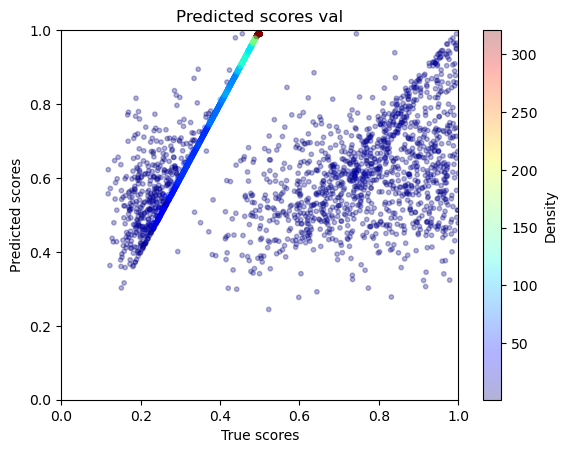

NameError: name 'modified_valid_pred_scores' is not defined

In [46]:
def scatter(x, y, x_label, y_label, title=''):
    density, x_edges, y_edges = np.histogram2d(x, y, bins=50, range=[[0, 1], [0, 1]])

    # plt.plot([0,1], [0,1], color="red")
    plt.scatter(x, y, c=[density[np.digitize(x, x_edges[1:-1]),
                                 np.digitize(y, y_edges[1:-1])]],
                                 cmap='jet', s=10, alpha=0.3)
    plt.colorbar(label='Density')
    plt.xlim([0,1])
    plt.ylim([0,1])
#     plt.scatter(x, y, alpha = 0.1)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

scatter(valid_true_scores, valid_pred_scores,
        'True scores', 'Predicted scores', 'Predicted scores val')

scatter(valid_true_scores, modified_valid_pred_scores,
        'True scores', 'Predicted scores + correction', 'Modified scored val')


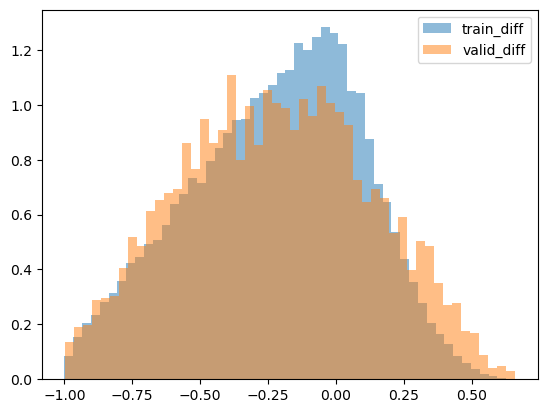

In [69]:
_ = plt.hist(calib_true_scores - calib_pred_scores, bins=50, label='train_diff', alpha=0.5, density=True)
_ = plt.hist(valid_true_scores - valid_pred_scores, bins=50, label='valid_diff', alpha=0.5, density=True)
plt.legend()